# Arrays, meshes, and sharding

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization so you can practice multi-device sharding locally.

- Translate a PartitionSpec into local shard shapes.
- Inspect shard indices and verify values.
- Explain communication needs of a global reduction.
- Repair uneven batch statistics with padding and masks.

We can split examples across devices, split features across devices, or keep a full copy on each one. Let’s make those choices visible on four logical CPU devices. You’ll inspect the pieces and see why some reductions must combine results. No cluster is needed, and these observations do not measure accelerator performance.

## The idea

Sharding places one global array across a named mesh. Global shape, local shard shape and replication describe different views of the same computation. Make ownership explicit before reasoning about communication.

## Compare the global array with each local piece

A four-by-four array on two devices can be split into two-by-four row shards or four-by-two column shards. Both layouts contain the same global values. Their local operations and communication requirements differ.

Replication gives each participant the full value instead of a disjoint portion. Use explicit labels so duplicated ownership cannot be mistaken for partitioning.

Connect each PartitionSpec entry to its array axis and named mesh axis. Inspect actual addressable shards and compare reconstructed values with a global reference. Logical CPU devices validate this placement exercise without reproducing a multi-host network.

$$
\text{Mesh}(D, (\texttt{'data'}, \texttt{'model'})) \implies \operatorname{shard}(X) \in \mathbb{R}^{(B/P_d) \times (H/P_m)}
$$

### Pause and reason

Must changing row sharding to column sharding change the answer?

<details><summary>Compare your reasoning</summary>

No. A correct compatible computation preserves the intended global result. Storage and communication can change even when the result agrees.

</details>

## Read the mapping from left to right

Start with eight rows and four columns. Our one-dimensional mesh contains four devices along data. `P("data",None)` partitions eight rows into four groups of two and preserves four features per shard. `P(None,"data")` leaves rows intact and assigns one of four columns to each device. The same global shape supports both arrangements.

None means an array dimension is not partitioned by this specification, not that the values are missing. `P()` replicates the whole array. A device mesh axis may not be reused across multiple array dimensions within one PartitionSpec. More complex two-dimensional meshes need distinct axis names and a reason for assigning each dimension.

```text
Array (8,4) → P(data,None) → 4 pieces (2,4)
Array (8,4) → P(None,data) → 4 pieces (8,1)
Array (8,4) → P() → 4 full copies (8,4)
```

## Inspect indices rather than guessing ordering

addressable_shards lists pieces this process can access. Each piece carries a device, global index and data. For row partitioning the indices select successive two-row slices; for column partitioning they select individual columns. Compare host[shard.index] with shard.data. This catches a mismatch between the intended assignment and the actual data.

All four devices are addressable here because we have one process. In a multi-process program, the global device set may include devices another process owns. `np.asarray` on a global array that is not fully addressable is not a general multi-host gathering recipe. This lesson deliberately exercises only the single-process case.

## A reduction has a communication requirement

For rows $0$ through $31$ reshaped to $(8,4)$, the first column is $0$,$4$,$8$,$12$,$16$,$20$,$24$,$28$ and sums to $112$. Each row shard can sum its own two rows, but no one shard initially sees all eight. Producing a replicated global column sum requires combining contributions across the data axis.

We use a jitted ordinary sum and declare replicated output. JAX compiles the placement-aware global operation and arranges necessary communication. The source-level need to combine partial sums is a reasoning argument; exact collective lowering is compiler/version dependent and would require lowered code or profiler evidence to characterize. This CPU lesson does not estimate accelerator communication latency.

```text
partial sums device 0: [4,6,8,10]
partial sums device 1: [20,22,24,26]
partial sums device 2: [36,38,40,42]
partial sums device 3: [52,54,56,58]
combine → [112,120,128,136]
```

## Choose placement for the operation you will perform and run it on a TPU mesh

Elementwise functions naturally preserve local independence. Reductions across a partitioned dimension and matrix multiplications can require communication. Choosing columns instead of rows changes which values are locally available; it does not alter the mathematical answer.

`device_put` from a host NumPy array places that array according to the requested sharding. Moving an already placed JAX array to a different sharding is a resharding operation. Host reconstruction is useful for our tiny verification case but should not be inserted into a real training loop. The experiments compare two layouts for correctness, not speed. Save global shapes, specs and shard tables as the evidence needed to reason about a future workload.

To run this exact mesh and `NamedSharding` contract on a real 4-chip TPU VM (for example `v5litepod-4` or `v6e-4`, provisioned via `lesson-welcome-03.html` and `tpu-gcp.html`), remove the `jax_platforms=cpu` override so `jax.devices()` discovers the four physical TPU chips. On a multi-host TPU slice (`v5litepod-8` or larger), call `jax.distributed.initialize()` at process startup and launch across all workers with `--worker=all`.

**Run the 4-device sharding check on a 4-chip TPU VM (single host)**

```bash
gcloud compute tpus tpu-vm scp exercises/distributed-01.py $TPU_NAME:~/jax-tpu-lab/ --zone=$ZONE
gcloud compute tpus tpu-vm ssh $TPU_NAME --zone=$ZONE \
  --command="sed 's/jax.config.update(\"jax_platforms\", \"cpu\")/# use default TPU backend/; s/jax.devices(\"cpu\")/jax.devices()[:4]/' ~/jax-tpu-lab/distributed-01.py > ~/jax-tpu-lab/distributed-01-tpu.py && JAX_PLATFORMS=tpu ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/distributed-01-tpu.py"
```

**Expected:** Places the (8, 4) array across four TPU chips, verifies row-shard (2, 4) and column-shard (8, 1) local shapes, and checks the replicated column sum [112, 120, 128, 136].

## Start a fresh CPU runtime

Create main.py in your course workspace. Paste this block first. If using a notebook, restart its kernel before running any cell.

In [1]:
# Step 1 — Start a fresh CPU runtime: Configuration happens before devices() or array creation...
# Import jax for this computation.
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
# Update state in place with the new values.
jax.config.update("jax_num_cpu_devices", 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
# Query the active JAX devices into `devices`.
devices = jax.devices("cpu")
# Guard input contract (`len(devices) != 4`) and fail fast if violated.
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.array(devices), ("data",))
# Configure multi-device placement / sharding specification (`rows`).
rows = NamedSharding(mesh, P("data", None))
# Configure multi-device placement / sharding specification (`replicated`).
replicated = NamedSharding(mesh, P())

Configuration happens before `devices()` or array creation initializes a backend. This file explicitly chooses CPU even on a GPU machine.

## Place and compute

Append this block in the same file. Predict the shapes and values before running.

In [2]:
# Step 2 — Place and compute: Mesh axis names describe placement.
# Construct and reshape `host` into the target tensor dimensions.
host = np.arange(32, dtype=np.float32).reshape(8,4)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(host, rows)
# Configure multi-device placement / sharding specification (`columns`).
columns = NamedSharding(mesh, P(None, "data"))
# Place `x_columns` explicitly onto the target JAX device.
x_columns = jax.device_put(host, columns)
# Wrap with `jax.jit` (`sum_rows`) so XLA traces and compiles the function.
sum_rows = jax.jit(lambda a:a.sum(axis=0), in_shardings=rows, out_shardings=replicated)(x)
# Synchronize host execution until asynchronous device computation completes.
sum_rows.block_until_ready()

Mesh axis names describe placement. They are separate from the numerical array dimensions.

## Inspect and verify

Append the checks, save the file and run python main.py with the setup lesson environment.

In [3]:
# Step 3 — Inspect and verify: Assertions compare against host calculations or hand-derived...
np.testing.assert_array_equal(np.asarray(sum_rows), np.array([112,120,128,136],dtype=np.float32))
# Iterate over `shard` to step through the computation:
for shard in x.addressable_shards:
    # Check tensor shape invariant: `shard.data.shape == (2,4)`
    assert shard.data.shape == (2,4)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
# Iterate over `shard` to step through the computation:
for shard in x_columns.addressable_shards:
    # Check tensor shape invariant: `shard.data.shape == (8,1)`
    assert shard.data.shape == (8,1)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
# Print the observed values to compare against the expected result.
print("Row-shard shapes:", [s.data.shape for s in x.addressable_shards])
# Print diagnostic summary of the computed outputs.
print("Column-shard shapes:", [s.data.shape for s in x_columns.addressable_shards])
# Print diagnostic summary of the computed outputs.
print("Column sums:", np.asarray(sum_rows))

Row-shard shapes: [(2, 4), (2, 4), (2, 4), (2, 4)]
Column-shard shapes: [(8, 1), (8, 1), (8, 1), (8, 1)]
Column sums: [112. 120. 128. 136.]


Assertions compare against host calculations or hand-derived values; printing a sharding object alone is separate from correctness.

## Run the example

In [4]:
# Step 1 — Start a fresh CPU runtime: Configuration happens before devices() or array creation...
# Import jax for this computation.
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
# Update state in place with the new values.
jax.config.update("jax_num_cpu_devices", 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
# Query the active JAX devices into `devices`.
devices = jax.devices("cpu")
# Guard input contract (`len(devices) != 4`) and fail fast if violated.
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.array(devices), ("data",))
# Configure multi-device placement / sharding specification (`rows`).
rows = NamedSharding(mesh, P("data", None))
# Configure multi-device placement / sharding specification (`replicated`).
replicated = NamedSharding(mesh, P())

# Step 2 — Place and compute: Mesh axis names describe placement.
# Construct and reshape `host` into the target tensor dimensions.
host = np.arange(32, dtype=np.float32).reshape(8,4)
# Place `x` explicitly onto the target JAX device.
x = jax.device_put(host, rows)
# Configure multi-device placement / sharding specification (`columns`).
columns = NamedSharding(mesh, P(None, "data"))
# Place `x_columns` explicitly onto the target JAX device.
x_columns = jax.device_put(host, columns)
# Wrap with `jax.jit` (`sum_rows`) so XLA traces and compiles the function.
sum_rows = jax.jit(lambda a:a.sum(axis=0), in_shardings=rows, out_shardings=replicated)(x)
# Synchronize host execution until asynchronous device computation completes.
sum_rows.block_until_ready()

# Step 3 — Inspect and verify: Assertions compare against host calculations or hand-derived...
np.testing.assert_array_equal(np.asarray(sum_rows), np.array([112,120,128,136],dtype=np.float32))
# Iterate over `shard` to step through the computation:
for shard in x.addressable_shards:
    # Check tensor shape invariant: `shard.data.shape == (2,4)`
    assert shard.data.shape == (2,4)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
# Iterate over `shard` to step through the computation:
for shard in x_columns.addressable_shards:
    # Check tensor shape invariant: `shard.data.shape == (8,1)`
    assert shard.data.shape == (8,1)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
# Print the observed values to compare against the expected result.
print("Row-shard shapes:", [s.data.shape for s in x.addressable_shards])
# Print diagnostic summary of the computed outputs.
print("Column-shard shapes:", [s.data.shape for s in x_columns.addressable_shards])
# Print diagnostic summary of the computed outputs.
print("Column sums:", np.asarray(sum_rows))

Row-shard shapes: [(2, 4), (2, 4), (2, 4), (2, 4)]
Column-shard shapes: [(8, 1), (8, 1), (8, 1), (8, 1)]
Column sums: [112. 120. 128. 136.]


Expected: Four row shards $(2,4)$; four column shards $(8,1)$. Column sums $[112,120,128,136]$.

## Row sharding and column sharding place the same array differently

Predict: Which dimension is split across devices in each panel?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Row sharding and column sharding place the same array differently
# Compute `panels` from `[]`
panels = []
# Loop over `(name, array)` in `[('Row partition', x), ('Column partition', x_columns)]`:
for name, array in [('Row partition', x), ('Column partition', x_columns)]:
    # Run `np.empty` to compute `owner`.
    owner = np.empty(host.shape, dtype=int)
    # Loop over `s` in `array.addressable_shards`:
    for s in array.addressable_shards:
        # Compute `owner[s.index]` from `s.device.id`
        owner[s.index] = s.device.id
    # Append the current step result to `panels`.
    panels.append({'kind': 'heatmap', 'title': name, 'values': owner.tolist(), 'unit': 'logical CPU device ID'})
# Compute `visual_data` from `{'kind': 'panels', 'panels': panels}`
visual_data = {'kind': 'panels', 'panels': panels}

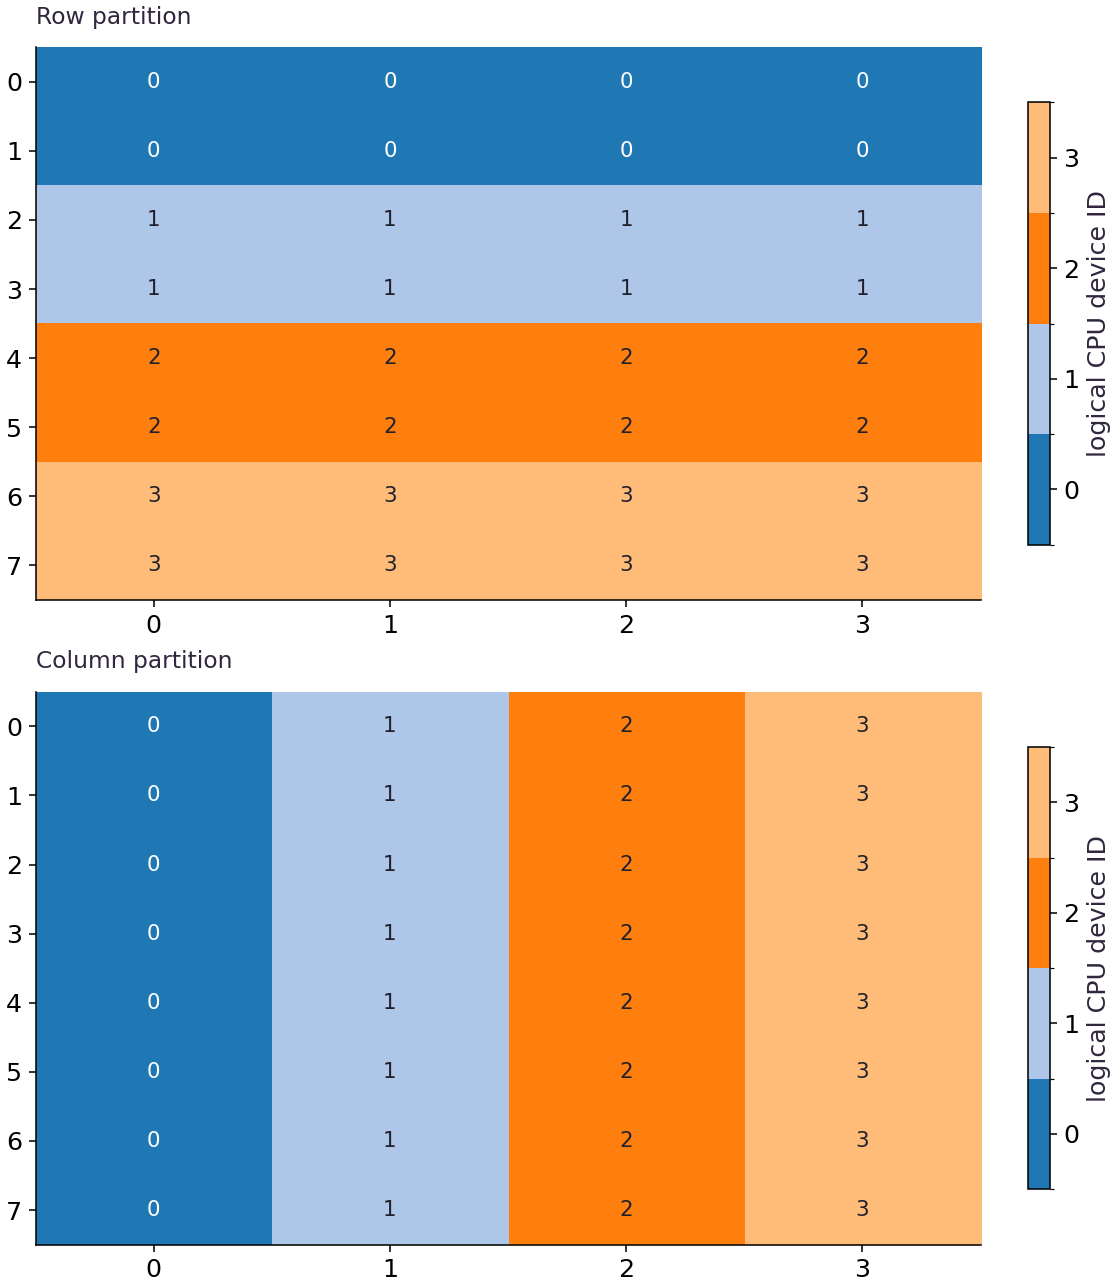

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Both panels represent the same global array with shape $(8,4)$. Each cell’s number and color identify its owning logical device, not the array value stored there. Device colors are categorical and do not rank speed or capacity.

In the upper panel, each device owns two complete rows: device $0$ owns rows $0$ and $1$, for example. In the lower panel, each device owns one complete column across all eight rows. The horizontal bands become vertical bands when the partitioned axis changes.

### Connect it to the computation

Each device owns eight scalar entries in either layout, but their local shapes differ: $(2,4)$ for row partitioning and $(8,1)$ for column partitioning. Equal local element counts do not mean that the same operations will have the same communication needs.

For example, a whole row is locally available in the upper layout but split across devices in the lower one. A row-wise reduction therefore has different placement implications. The figure establishes ownership only; communication volume and execution time are not measured, and these four logical devices share one CPU host.

## Reshard the same global values

Predict: Moving $x$ from row partitioning to column partitioning changes local shapes. Does it change the global values?

In [7]:
# Experiment — Reshard the same global values: Resharding changes ownership of values, not their mathematical...
moved = jax.device_put(x, columns)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_array_equal(np.asarray(moved), host)
# Check tensor shape invariant: `all(s.data.shape == (8,1) for s in moved.addressable_shards)`
assert all(s.data.shape == (8,1) for s in moved.addressable_shards)
# Print the observed values to compare against the expected result.
print("Resharded values preserved")

Resharded values preserved


Expected: Global array unchanged; local shards now $(8,1)$.

Resharding changes ownership of values, not their mathematical identity.

## Reduce a dimension that is not partitioned

Predict: Sum each row. Predict the output shape and which mesh axis should partition it.

In [8]:
# Experiment — Reduce a dimension that is not partitioned: All four columns for a row are already local in row...
# Configure multi-device placement / sharding specification (`vector_rows`).
vector_rows = NamedSharding(mesh, P("data"))
# Wrap with `jax.jit` (`per_row`) so XLA traces and compiles the function.
per_row = jax.jit(lambda a:a.sum(axis=1), in_shardings=rows, out_shardings=vector_rows)(x)
# Create evenly spaced index values in ``.
np.testing.assert_array_equal(np.asarray(per_row), np.arange(6,119,16,dtype=np.float32))
# Check tensor shape invariant: `all(s.data.shape == (2,) for s in per_row.addressable_shards)`
assert all(s.data.shape == (2,) for s in per_row.addressable_shards)
# Print the observed values to compare against the expected result.
print("Row sums:", np.asarray(per_row))

Row sums: [  6.  22.  38.  54.  70.  86. 102. 118.]


Expected: Row sums $[6,22,38,54,70,86,102,118]$; local shapes $(2,)$.

All four columns for a row are already local in row partitioning; this reduction does not mathematically require combining data-axis pieces.

## Your exercise

Compare row and column layouts of a $(12,8)$ array, and repair a ten-row mean with padding plus an explicit mask.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.

**Step-by-step implementation plan:**
1. Construct and reshape `other` into the target tensor dimensions.
2. Iterate over `(spec, expected)` to step through the computation:
3. Place `placed` explicitly onto the target JAX device.
4. Iterate over `shard` to step through the computation:
5. Check tensor shape invariant: `shard.data.shape == expected`

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compare row and column layouts of a (12,8) array, and repair a ten-row...
# Construct and reshape `other` into the target tensor dimensions.
other = np.arange(...)  # TODO: compute other
# Iterate over `(spec, expected)` to step through the computation:
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
    placed = jax.device_put(...)  # TODO: compute placed
    # Iterate over `shard` to step through the computation:
    for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
        assert shard.data.shape  # TODO: complete assertion check
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

# Construct and reshape `original` into the target tensor dimensions.
original = np.arange(...)  # TODO: compute original
# Run the boundary check and catch the expected exception:
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
padded = jax.device_put(...)  # TODO: compute padded
# Configure multi-device placement / sharding specification (`mask_sharding`).
mask_sharding = NamedSharding(...)  # TODO: compute mask_sharding
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
mask = jax.device_put(...)  # TODO: compute mask
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
masked_mean = jax.jit(...)  # TODO: compute masked_mean
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis = ...  # TODO: compute np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compare row and column layouts of a (12,8) array, and repair a ten-row...
# Construct and reshape `other` into the target tensor dimensions.
# other = np.arange(...)  # TODO: compute other
# Iterate over `(spec, expected)` to step through the computation:
# for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
#     placed = jax.device_put(...)  # TODO: compute placed
    # Iterate over `shard` to step through the computation:
#     for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
#         assert shard.data.shape  # TODO: complete assertion check
        # Convert `` to a host NumPy array for inspection or verification.
#         np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

# Construct and reshape `original` into the target tensor dimensions.
# original = np.arange(...)  # TODO: compute original
# Run the boundary check and catch the expected exception:
# try:
#     jax.device_put(original, rows)
# except ValueError:
#     print("Expected indivisible batch")
# else:
#     raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
# padded = jax.device_put(...)  # TODO: compute padded
# Configure multi-device placement / sharding specification (`mask_sharding`).
# mask_sharding = NamedSharding(...)  # TODO: compute mask_sharding
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
# mask = jax.device_put(...)  # TODO: compute mask
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
# masked_mean = jax.jit(...)  # TODO: compute masked_mean
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis = ...  # TODO: compute np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
# assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Compare row and column layouts of a (12,8) array, and repair a ten-row...
# Construct and reshape `other` into the target tensor dimensions.
other = np.arange(96,dtype=np.float32).reshape(12,8)
# Iterate over `(spec, expected)` to step through the computation:
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
    placed = jax.device_put(other,spec)
    # Iterate over `shard` to step through the computation:
    for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
        assert shard.data.shape == expected
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

# Construct and reshape `original` into the target tensor dimensions.
original = np.arange(40,dtype=np.float32).reshape(10,4)
# Run the boundary check and catch the expected exception:
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
padded = jax.device_put(np.pad(original,((0,2),(0,0))),rows)
# Configure multi-device placement / sharding specification (`mask_sharding`).
mask_sharding = NamedSharding(mesh,P("data"))
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
mask = jax.device_put(np.array([1]*10+[0]*2,dtype=np.float32),mask_sharding)
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
masked_mean = jax.jit(lambda a,m:(a*m[:,None]).sum(axis=0)/m.sum(),in_shardings=(rows,mask_sharding),out_shardings=replicated)(padded,mask)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis=0),rtol=1e-6)
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))

Expected indivisible batch


## Change both dimensions · Challenge

Use a $(12,8)$ array. Verify row and column layouts and predict every local shape.

Hint: Four devices divide twelve rows or eight columns.

### How to write: Change both dimensions — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `Mesh + PartitionSpec + NamedSharding` — Maps logical tensor axes onto physical device mesh axes for SPMD data, tensor, or pipeline parallelism.

**Step-by-step implementation plan:**
1. Construct and reshape `other` into the target tensor dimensions.
2. Iterate over `(spec, expected)` to step through the computation:
3. Place `placed` explicitly onto the target JAX device.
4. Iterate over `shard` to step through the computation:
5. Check tensor shape invariant: `shard.data.shape == expected`

**Starter code scaffold (fill in the TODOs):**

```python
# Change both dimensions (Challenge): The row layout owns three complete feature vectors per...
# Construct and reshape `other` into the target tensor dimensions.
other = np.arange(...)  # TODO: compute other
# Iterate over `(spec, expected)` to step through the computation:
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
    placed = jax.device_put(...)  # TODO: compute placed
    # Iterate over `shard` to step through the computation:
    for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
        assert shard.data.shape  # TODO: complete assertion check
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Change both dimensions (Challenge): The row layout owns three complete feature vectors per...
# Construct and reshape `other` into the target tensor dimensions.
# other = np.arange(...)  # TODO: compute other
# Iterate over `(spec, expected)` to step through the computation:
# for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
#     placed = jax.device_put(...)  # TODO: compute placed
    # Iterate over `shard` to step through the computation:
#     for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
#         assert shard.data.shape  # TODO: complete assertion check
        # Convert `` to a host NumPy array for inspection or verification.
#         np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

## Reference reasoning

The row layout owns three complete feature vectors per device; the column layout owns two features for every observation.

In [12]:
# Change both dimensions (Challenge): The row layout owns three complete feature vectors per...
# Construct and reshape `other` into the target tensor dimensions.
other = np.arange(96,dtype=np.float32).reshape(12,8)
# Iterate over `(spec, expected)` to step through the computation:
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    # Place `placed` explicitly onto the target JAX device.
    placed = jax.device_put(other,spec)
    # Iterate over `shard` to step through the computation:
    for shard in placed.addressable_shards:
        # Check tensor shape invariant: `shard.data.shape == expected`
        assert shard.data.shape == expected
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

## Pad an uneven batch without corrupting its mean · Challenge

Ten observations cannot be row-partitioned over four devices. Pad to twelve and use a mask to recover the true column mean. Demonstrate the wrong unmasked mean.

Hint: The divisor is the sum of the mask, not padded length.

### How to write: Pad an uneven batch without corrupting its mean — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.jit(fn) / @jax.jit` — Traces `fn` with abstract shapes and compiles a fused XLA executable cached by input shape and dtype.

**Step-by-step implementation plan:**
1. Construct and reshape `original` into the target tensor dimensions.
2. Run the boundary check and catch the expected exception:
3. Place `padded` explicitly onto the target JAX device.
4. Configure multi-device placement / sharding specification (`mask_sharding`).
5. Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`

**Starter code scaffold (fill in the TODOs):**

```python
# Pad an uneven batch without corrupting its mean (Challenge): Padding repairs the shape but adds artificial rows.
# Construct and reshape `original` into the target tensor dimensions.
original = np.arange(...)  # TODO: compute original
# Run the boundary check and catch the expected exception:
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
padded = jax.device_put(...)  # TODO: compute padded
# Configure multi-device placement / sharding specification (`mask_sharding`).
mask_sharding = NamedSharding(...)  # TODO: compute mask_sharding
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
mask = jax.device_put(...)  # TODO: compute mask
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
masked_mean = jax.jit(...)  # TODO: compute masked_mean
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis = ...  # TODO: compute np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Pad an uneven batch without corrupting its mean (Challenge): Padding repairs the shape but adds artificial rows.
# Construct and reshape `original` into the target tensor dimensions.
# original = np.arange(...)  # TODO: compute original
# Run the boundary check and catch the expected exception:
# try:
#     jax.device_put(original, rows)
# except ValueError:
#     print("Expected indivisible batch")
# else:
#     raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
# padded = jax.device_put(...)  # TODO: compute padded
# Configure multi-device placement / sharding specification (`mask_sharding`).
# mask_sharding = NamedSharding(...)  # TODO: compute mask_sharding
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
# mask = jax.device_put(...)  # TODO: compute mask
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
# masked_mean = jax.jit(...)  # TODO: compute masked_mean
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis = ...  # TODO: compute np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
# assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))  # TODO: complete assertion check

## Reference reasoning

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

In [14]:
# Pad an uneven batch without corrupting its mean (Challenge): Padding repairs the shape but adds artificial rows.
# Construct and reshape `original` into the target tensor dimensions.
original = np.arange(40,dtype=np.float32).reshape(10,4)
# Run the boundary check and catch the expected exception:
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
# Place `padded` explicitly onto the target JAX device.
padded = jax.device_put(np.pad(original,((0,2),(0,0))),rows)
# Configure multi-device placement / sharding specification (`mask_sharding`).
mask_sharding = NamedSharding(mesh,P("data"))
# Compute `mask` from `jax.device_put(np.array([1]*10+[0]*2,dtype=np.float3...`
mask = jax.device_put(np.array([1]*10+[0]*2,dtype=np.float32),mask_sharding)
# Wrap with `jax.jit` (`masked_mean`) so XLA traces and compiles the function.
masked_mean = jax.jit(lambda a,m:(a*m[:,None]).sum(axis=0)/m.sum(),in_shardings=(rows,mask_sharding),out_shardings=replicated)(padded,mask)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis=0),rtol=1e-6)
# Assert that `not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))`.
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))

Expected indivisible batch


## Checkpoint

With row sharding, why does a global column sum need results from other devices?

1. Each device initially holds only some rows.
2. Every sum requires host Python.
3. Partitioning changes the mathematical definition of sum.

## Diagnose

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

## Evidence

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

## Carry forward

- Read the mapping from left to right
- Inspect indices rather than guessing ordering
- A reduction has a communication requirement
- Choose placement for the operation you will perform

## Primary references

- [JAX CPU device configuration (set before initialization)](https://docs.jax.dev/en/latest/config_options.html#num-cpu-devices)
- [Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)